In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from reproject import reproject_interp
from astropy.visualization import make_lupton_rgb
from astropy.wcs import utils
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle
from matplotlib.patches import ConnectionPatch
from astropy.visualization import ImageNormalize, LogStretch, LinearStretch
from matplotlib.patches import FancyArrowPatch
import astropy.units as u



Function to orient images North


In [2]:
def orient_north(input_fits_path, output_fits_path, pad_factor):
    # Load FITS
    with fits.open(input_fits_path) as hdu:
        # hdu = hdul[0]
        data = hdu[1].data
        # header = hdu.header
        wcs = WCS(hdu[1].header)
        data[np.isnan(data)] = 0
        data[data<0] = 0.01

        # Get original shape
        ny, nx = data.shape

        # New shape with padding
        pad_nx = int(nx * pad_factor)
        pad_ny = int(ny * pad_factor)

        # Create new WCS header for North-up orientation
        header_north = wcs.deepcopy().to_header()

        # Force PC matrix to identity (North-up)
        header_north['PC1_1'] = 1
        header_north['PC1_2'] = 0
        header_north['PC2_1'] = 0
        header_north['PC2_2'] = 1

        # Adjust reference pixel to be in the center of the new image
        header_north['NAXIS1'] = pad_nx
        header_north['NAXIS2'] = pad_ny
        header_north['CRPIX1'] = pad_nx / 2
        header_north['CRPIX2'] = pad_ny / 2

        wcs_north = WCS(header_north)

        # Reproject
        reprojected_data, _ = reproject_interp((data, wcs), wcs_north, shape_out=(pad_ny, pad_nx))

        # Save output
        fits.writeto(output_fits_path, reprojected_data, wcs_north.to_header(), overwrite=True)
        
    return reprojected_data

In [30]:
# path = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/lvl_3/'
# npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'

# nir1 = 'jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'
# nir2 = 'jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits'
# nir3 = 'jw02107-o021_t003_nircam_clear-f335m_jhat_i2d.fits'
# nir4 = 'jw02107-o021_t003_nircam_clear-f360m_jhat_i2d.fits'
# miri1 = 'jw02107-c1003_t003_miri_f770w_jhat_i2d.fits'
# miri2 = 'jw02107-c1003_t003_miri_f1000w_jhat_i2d.fits'
# miri3 = 'jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'
# miri4 = 'jw02107-c1003_t003_miri_f2100w_jhat_i2d.fits'

# miri_files = [path+miri1, path+miri2,path+miri3, path+miri4]
# nir_files = [path+nir1, path+nir2,path+nir3, path+nir4]
# mtitles = ['f770w','f1000w','f1130w',"f2100w"]
# ntitles = ['f200w','f300m','f335m',"f360m"]

# for mfile in range(len(miri_files)):
#     orient_north(miri_files[mfile],npath+'North_'+mtitles[mfile],pad_factor=2.0)
# for nfile in range(len(nir_files)):
#     orient_north(nir_files[nfile],npath+'North_'+ntitles[nfile],pad_factor=2.0)

In [3]:
npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
nir_north_files = [npath+'North_f200w.fits',npath+'North_f300m.fits',npath+'North_f335m.fits',npath+"North_f360m.fits"]
miri_north_files = [npath+'North_f770w.fits',npath+'North_f1000w.fits',npath+'North_f1130w.fits',npath+"North_f2100w.fits"]

# Open all fits images
nir1_hdu     = fits.open(nir_north_files[0])
nir2_hdu     = fits.open(nir_north_files[1])
nir3_hdu     = fits.open(nir_north_files[2])
nir4_hdu     = fits.open(nir_north_files[3])
miri770_hdu  = fits.open(miri_north_files[0])
miri1000_hdu = fits.open(miri_north_files[1])
miri1130_hdu = fits.open(miri_north_files[2])
miri2100_hdu = fits.open(miri_north_files[3])


nir_200_data_r     = nir1_hdu[0].data
nir_300_data_r     = nir2_hdu[0].data
nir_335_data_r     = nir3_hdu[0].data
nir_360_data_r     = nir4_hdu[0].data
miri_770_data_r    = miri770_hdu[0].data
miri_1000_data_r   = miri1000_hdu[0].data
miri_1130_data_r   = miri1130_hdu[0].data
miri_2100_data_r   = miri2100_hdu[0].data




In [4]:
wcs_200  = WCS(nir1_hdu[0].header)
wcs_300  = WCS(nir2_hdu[0].header)
wcs_335  = WCS(nir3_hdu[0].header)
wcs_360  = WCS(nir4_hdu[0].header)
wcs_770  = WCS(miri770_hdu[0].header)
wcs_1000 = WCS(miri1000_hdu[0].header)
wcs_1130 = WCS(miri1130_hdu[0].header)
wcs_2100 = WCS(miri2100_hdu[0].header)

Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.436458 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645548163.890 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.430943 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645470550.812 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
# Handle Nans; set Nans to 0
nir_200_data_r[np.isnan(nir_200_data_r)] = 0
nir_300_data_r[np.isnan(nir_300_data_r)] = 0
nir_335_data_r[np.isnan(nir_335_data_r)] = 0
nir_360_data_r[np.isnan(nir_360_data_r)] = 0
miri_770_data_r[np.isnan(miri_770_data_r)] = 0
miri_1000_data_r[np.isnan(miri_1000_data_r)] = 0
miri_1130_data_r[np.isnan(miri_1130_data_r)] = 0
miri_2100_data_r[np.isnan(miri_2100_data_r)] = 0

# How to handle negative values? Not sure. Going to set to 0
nir_200_data_r[nir_200_data_r<0] = 0.01
nir_300_data_r[nir_300_data_r<0] = 0.01
nir_335_data_r[nir_335_data_r<0] = 0.01
nir_360_data_r[nir_360_data_r<0] = 0.01
miri_770_data_r[miri_770_data_r<0] = 0.01
miri_1000_data_r[miri_1000_data_r<0] = 0.01
miri_1130_data_r[miri_1130_data_r<0] = 0.01
miri_2100_data_r[miri_2100_data_r<0] = 0.01

In [6]:
# NIRCAM Slicing
# Nircam_200 = [3423.2477, 7890.4207]
# Nircam_300 = [1640.652, 3825.5412]

# Image pixel location of SN 83V taken from DS9

# NIRCam 200
x200 = 3425
y200 = 7888

# NIRCam 300 - 360
x300 = 1641
y300 = 3823

# Crop image with indexing to focus on SN -- for cropping, [y,x]
window200 = 32
window300 = 16

# Crop region (same as before)
crop_nircam_200 = (slice(y200-window200, y200+window200), slice(x200-window200, x200+window200))
crop_nircam_300 = (slice(y300-window300, y300+window300), slice(x300-window300, x300+window300))

# MIRI Slicing
# Miri_770,1000,2100 = [4855.776, 4050.0799]
# Miri_1130 = [4850.2953, 4071.5223]

# Image pixel location of SN 83V taken from DS9
x700 = 4856
y700 = 4049

x1300 = 4850
y1300 = 4071
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 15

crop_miri = (slice(y700-window, y700+window), slice(x700-window, x700+window))
crop_miri_1130 = (slice(y1300-window, y1300+window), slice(x1300-window, x1300+window))



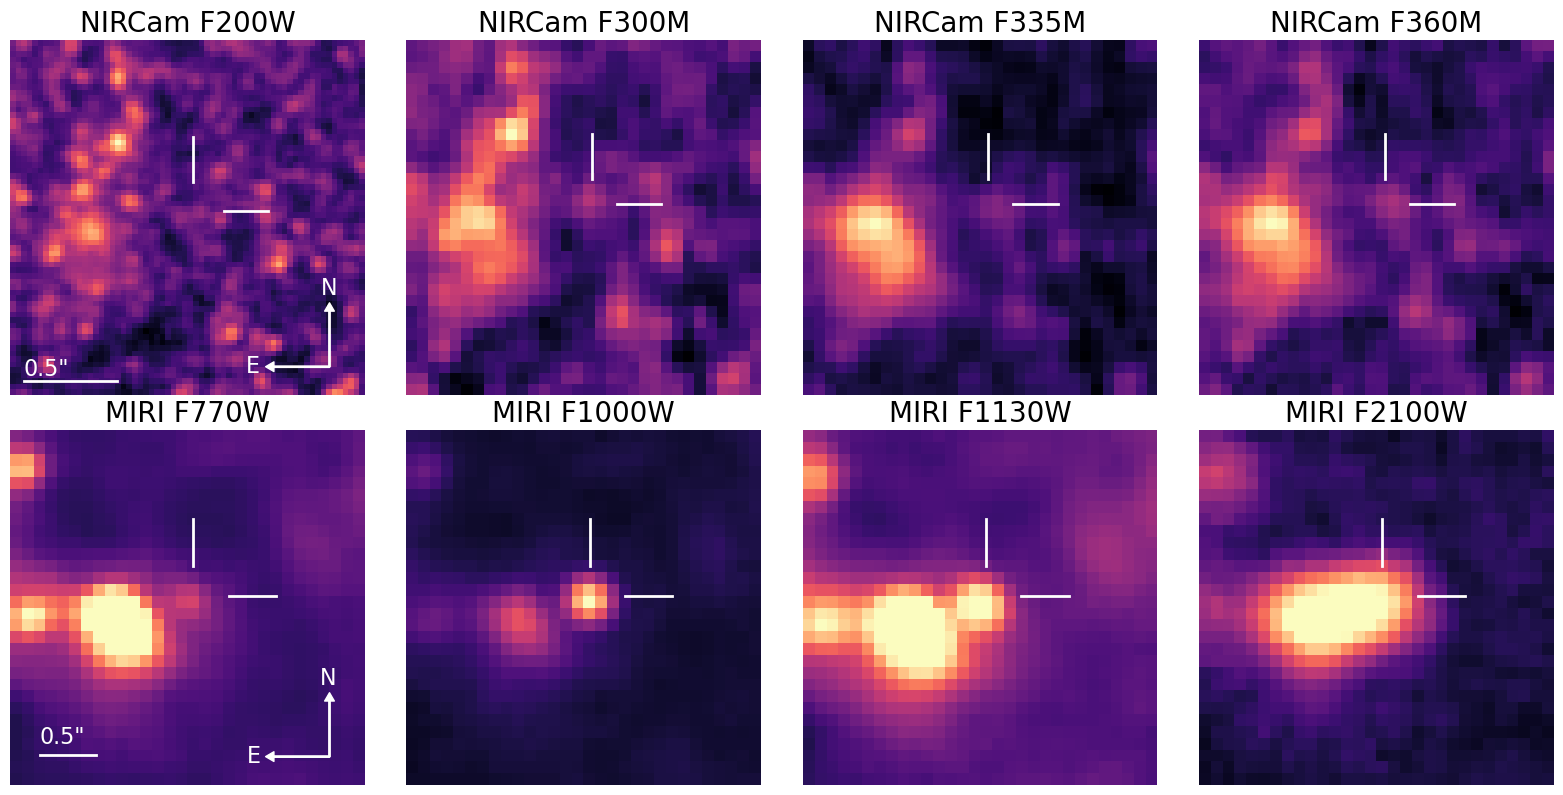

In [51]:
fig = plt.figure(figsize=(16, 8))

# Create axes with WCS projections
axs = [
    fig.add_subplot(2, 4, 1, projection=wcs_200),
    fig.add_subplot(2, 4, 2, projection=wcs_300),
    fig.add_subplot(2, 4, 3, projection=wcs_335),
    fig.add_subplot(2, 4, 4, projection=wcs_360),
    fig.add_subplot(2, 4, 5, projection=wcs_770),
    fig.add_subplot(2, 4, 6, projection=wcs_1000),
    fig.add_subplot(2, 4, 7, projection=wcs_1130),
    fig.add_subplot(2, 4, 8, projection=wcs_2100)
]
nir_norm = 'log'
mir_nor  = 'linear'
mvmin = -0.5
mvmax = 9
icmap = 'magma'

# First row: NIRCam images
axs[0].imshow(np.fliplr(nir_200_data_r[crop_nircam_200]), norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[1].imshow(np.fliplr(nir_300_data_r[crop_nircam_300]), norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[2].imshow(np.fliplr(nir_335_data_r[crop_nircam_300]), norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[3].imshow(np.fliplr(nir_360_data_r[crop_nircam_300]), norm=nir_norm, cmap=icmap, alpha=1, origin='lower')

# Second row: MIRI images
axs[4].imshow(np.fliplr(miri_770_data_r[crop_miri]), norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[5].imshow(np.fliplr(miri_1000_data_r[crop_miri]), norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[6].imshow(np.fliplr(miri_1130_data_r[crop_miri_1130]), norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[7].imshow(np.fliplr(miri_2100_data_r[crop_miri]), norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)

# Optional: remove axis ticks and add titles
titles = [
    'NIRCam F200W', 'NIRCam F300M', 'NIRCam F335M', 'NIRCam F360M',
    'MIRI F770W', 'MIRI F1000W', 'MIRI F1130W', 'MIRI F2100W'
]
for ax, title in zip(axs, titles):
    ax.set_title(title, fontsize=20)
    ax.axis('off')

# Cross hairs MIRI
hx_line = [(window)+3, (window)+7]
hy_line = [(window+0.5), (window+0.5)]

vx_line = [(window), (window)]
vy_line = [(window)+3, (window)+7]

axs[4].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[4].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[5].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[5].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[6].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[6].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[7].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[7].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

# Cross hairs NIRCam
# 200
hx_line200 = [(window200)+6, (window200)+14]
hy_line200 = [(window200+0.75), (window200+0.75)]

vx_line200 = [(window200+0.5), (window200+0.5)]
vy_line200 = [(window200)+6, (window200)+14]

# 300
hx_line300 = [(window300)+2.5, (window300)+6.5]
hy_line300 = [(window300+0.75), (window300+0.75)]

vx_line300 = [(window300+0.25), (window300+0.25)]
vy_line300 = [(window300)+3, (window300)+7]

# plot
axs[0].plot(hx_line200, hy_line200, color='white', linewidth=2, linestyle='-')
axs[0].plot(vx_line200, vy_line200, color='white', linewidth=2, linestyle='-')
axs[1].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[1].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')
axs[2].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[2].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')
axs[3].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[3].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')


# NIRcam 300+ Scale bar
# NIRCam = 0.5" = 8.5pixels
x0 = 2
y0 = 2
sc_x = [x0, x0+16.86] 
sc_y = [y0, y0]
axs[0].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
axs[0].text(2, 3, '0.5"', fontsize=16, color = 'white')

# MIRI Scale Bar
# MIRI = 0.5" = 4.8 pixels
x0 = 2
y0 = 2
sc_x = [x0, x0+4.8] 
sc_y = [y0, y0]
axs[4].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
axs[4].text(2, 3, '0.5"', fontsize=16, color = 'white')

# Add compass:
axs[0].annotate('', xy=(0.9, 0.26), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=1, headwidth=7, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')

axs[0].annotate('', xy=(0.72, 0.08), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=1, headwidth=7, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')

axs[4].annotate('', xy=(0.9, 0.26), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=1, headwidth=7, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')

axs[4].annotate('', xy=(0.72, 0.08), xytext=(0.9, 0.08),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(color='white', width=1, headwidth=7, headlength=6),
            horizontalalignment='center', verticalalignment='bottom',
            fontsize=16,color='white')
axs[4].text(25.7, 8, 'N', fontsize=16, color = 'white')
axs[0].text(55.5, 17.5, 'N', fontsize=16, color = 'white')

axs[0].text(42, 3.5, 'E', fontsize=16, color = 'white')
axs[4].text(19.5, 1.4, 'E', fontsize=16, color = 'white')

plt.tight_layout()
plt.savefig('/Users/sophiakressy/Desktop/all_filters_N.pdf')

In [2]:
path = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/lvl_3/'

nir1 = 'jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'
nir2 = 'jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits'
nir3 = 'jw02107-o021_t003_nircam_clear-f335m_jhat_i2d.fits'
nir4 = 'jw02107-o021_t003_nircam_clear-f360m_jhat_i2d.fits'
miri1 = 'jw02107-c1003_t003_miri_f770w_jhat_i2d.fits'
miri2 = 'jw02107-c1003_t003_miri_f1000w_jhat_i2d.fits'
miri3 = 'jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'
miri4 = 'jw02107-c1003_t003_miri_f2100w_jhat_i2d.fits'

miri_files = [path+miri1, path+miri2,path+miri3, path+miri4]
nir_files = [path+nir1, path+nir2,path+nir3, path+nir4]

# Open all fits images
nir1_hdu     = fits.open(nir_files[0])
nir2_hdu     = fits.open(nir_files[1])
nir3_hdu     = fits.open(nir_files[2])
nir4_hdu     = fits.open(nir_files[3])
miri770_hdu  = fits.open(miri_files[0])
miri1000_hdu = fits.open(miri_files[1])
miri1130_hdu = fits.open(miri_files[2])
miri2100_hdu = fits.open(miri_files[3])


nir_200_data     = nir1_hdu[1].data
nir_300_data     = nir2_hdu[1].data
nir_335_data     = nir3_hdu[1].data
nir_360_data     = nir4_hdu[1].data
miri_770_data    = miri770_hdu[1].data
miri_1000_data   = miri1000_hdu[1].data
miri_1130_data   = miri1130_hdu[1].data
miri_2100_data   = miri2100_hdu[1].data


In [3]:
# miri_770_header = miri770_hdu[1].header
# wcs = WCS(miri770_hdu[1].header)

wcs_200  = WCS(nir1_hdu[1].header)
wcs_300  = WCS(nir2_hdu[1].header)
wcs_335  = WCS(nir3_hdu[1].header)
wcs_360  = WCS(nir4_hdu[1].header)
wcs_770  = WCS(miri770_hdu[1].header)
wcs_1000 = WCS(miri1000_hdu[1].header)
wcs_1130 = WCS(miri1130_hdu[1].header)
wcs_2100 = WCS(miri2100_hdu[1].header)

Set DATE-AVG to '2022-08-13T18:06:02.506' from MJD-AVG.
Set DATE-END to '2022-08-13T19:05:49.676' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445500 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645675371.927 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T18:12:21.004' from MJD-AVG.
Set DATE-END to '2022-08-13T18:49:54.093' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.436458 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645548163.890 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T18:28:16.595' from MJD-AVG.
Set DATE-END to '2022-08-13T19:05:49.676' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.430943 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645470550.812 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T17:51:46.246' from MJD-AVG.
Set DATE-END to '2022-08-13T18:34:30.702' from MJD-END'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-08-13T15:46:20.295' from MJD-AVG.
Set DATE-END to '2022-08-13T18:20:48.239' from MJD-END'. [astropy.wcs

In [4]:
# Handle Nans; set Nans to 0
nir_200_data[np.isnan(nir_200_data)] = 0
nir_300_data[np.isnan(nir_300_data)] = 0
nir_335_data[np.isnan(nir_335_data)] = 0
nir_360_data[np.isnan(nir_360_data)] = 0
miri_770_data[np.isnan(miri_770_data)] = 0
miri_1000_data[np.isnan(miri_1000_data)] = 0
miri_1130_data[np.isnan(miri_1130_data)] = 0
miri_2100_data[np.isnan(miri_2100_data)] = 0

# How to handle negative values? Not sure. Going to set to 0
nir_200_data[nir_200_data<0] = 0.01
nir_300_data[nir_300_data<0] = 0.01
nir_335_data[nir_335_data<0] = 0.01
nir_360_data[nir_360_data<0] = 0.01
miri_770_data[miri_770_data<0] = 0.01
miri_1000_data[miri_1000_data<0] = 0.01
miri_1130_data[miri_1130_data<0] = 0.01
miri_2100_data[miri_2100_data<0] = 0.01

In [29]:
# NIRCAM Slicing

# Image pixel location of SN 83V taken from DS9

# NIRCam 200
x200 = 2589
y200 = 5374

# NIRCam 300 - 360
x300 = 1227
y300 = 2603

# Crop image with indexing to focus on SN -- for cropping, [y,x]
window200 = 32
window300 = 16

# Crop region (same as before)
crop_nircam_200 = (slice(y200-window200, y200+window200), slice(x200-window200, x200+window200))
crop_nircam_300 = (slice(y300-window300, y300+window300), slice(x300-window300, x300+window300))

# MIRI Slicing

# Image pixel location of SN 83V taken from DS9
x = 1139
y = 1243
# Crop image with indexing to focus on SN -- for cropping, [y,x]
window = 15
y0 = y-window
y1 = y+window
x0 = x-window
x1 = x+window

# Crop region (same as before)
crop_miri = (slice(y0, y1), slice(x0, x1))
crop_miri_1130 = (slice(y0, y1), slice(x0-2, x1-2))

print(crop_miri)

(slice(1228, 1258, None), slice(1124, 1154, None))


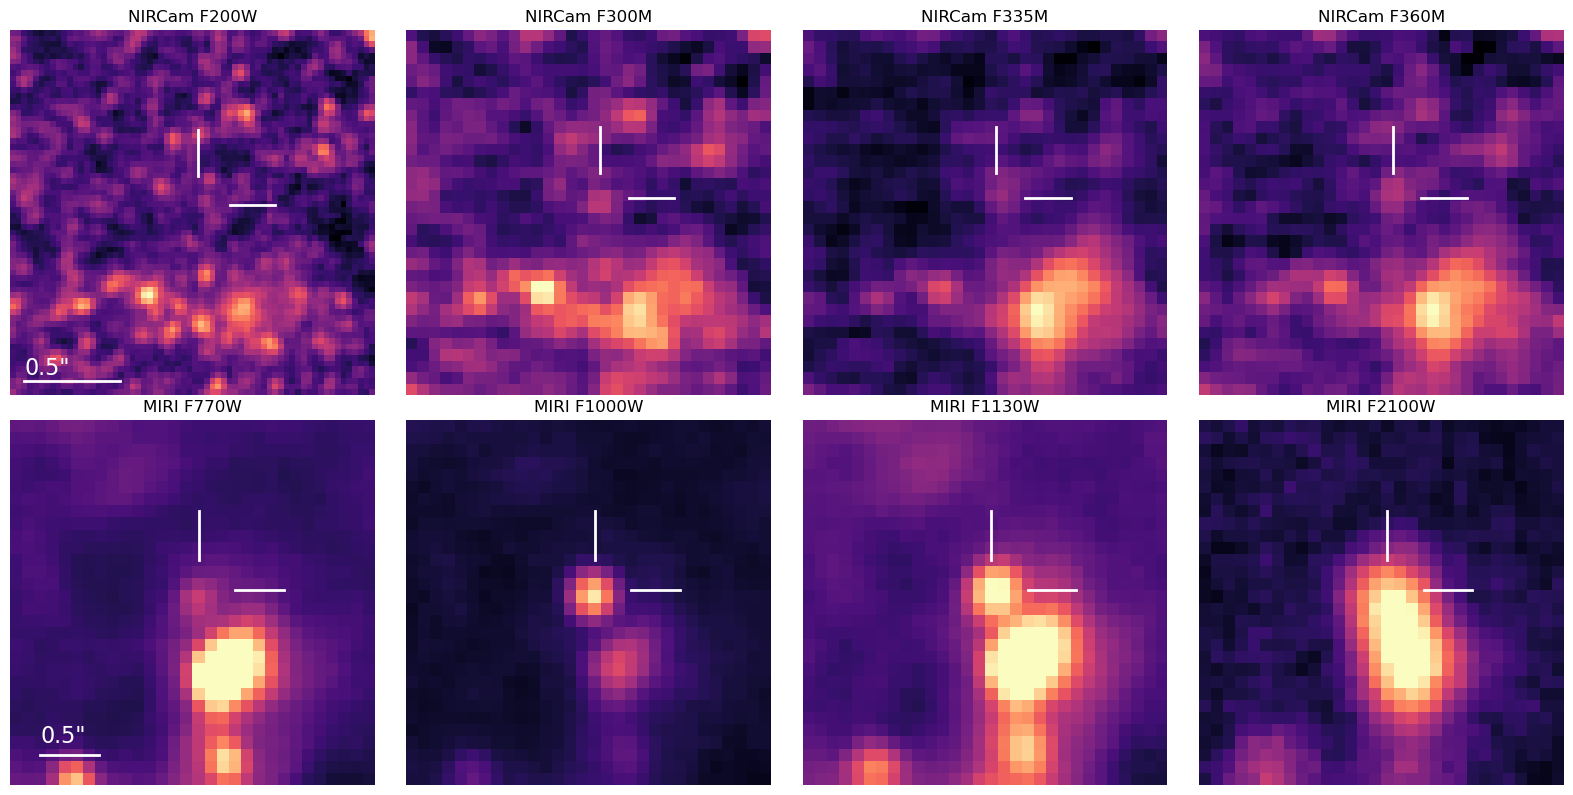

In [8]:
fig = plt.figure(figsize=(16, 8))

# Create axes with WCS projections
axs = [
    fig.add_subplot(2, 4, 1, projection=wcs_200),
    fig.add_subplot(2, 4, 2, projection=wcs_300),
    fig.add_subplot(2, 4, 3, projection=wcs_335),
    fig.add_subplot(2, 4, 4, projection=wcs_360),
    fig.add_subplot(2, 4, 5, projection=wcs_770),
    fig.add_subplot(2, 4, 6, projection=wcs_1000),
    fig.add_subplot(2, 4, 7, projection=wcs_1130),
    fig.add_subplot(2, 4, 8, projection=wcs_2100)
]
nir_norm = 'log'
mir_nor  = 'linear'
mvmin = -0.5
mvmax = 10
icmap = 'magma'

# First row: NIRCam images
axs[0].imshow(nir_200_data[crop_nircam_200], norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[1].imshow(nir_300_data[crop_nircam_300], norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[2].imshow(nir_335_data[crop_nircam_300], norm=nir_norm, cmap=icmap, alpha=1, origin='lower')
axs[3].imshow(nir_360_data[crop_nircam_300], norm=nir_norm, cmap=icmap, alpha=1, origin='lower')

# Second row: MIRI images
axs[4].imshow(miri_770_data[crop_miri], norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[5].imshow(miri_1000_data[crop_miri], norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[6].imshow(miri_1130_data[crop_miri_1130], norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)
axs[7].imshow(miri_2100_data[crop_miri], norm=mir_nor, cmap=icmap, alpha=1, origin='lower',vmin=mvmin,vmax=mvmax)

# Optional: remove axis ticks and add titles
titles = [
    'NIRCam F200W', 'NIRCam F300M', 'NIRCam F335M', 'NIRCam F360M',
    'MIRI F770W', 'MIRI F1000W', 'MIRI F1130W', 'MIRI F2100W'
]
for ax, title in zip(axs, titles):
    ax.set_title(title)
    ax.axis('off')

# Cross hairs MIRI
hx_line = [(window)+3, (window)+7]
hy_line = [(window+0.5), (window+0.5)]

vx_line = [(window), (window)]
vy_line = [(window)+3, (window)+7]

axs[4].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[4].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[5].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[5].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[6].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[6].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

axs[7].plot(hx_line, hy_line, color='white', linewidth=2, linestyle='-')
axs[7].plot(vx_line, vy_line, color='white', linewidth=2, linestyle='-')

# Cross hairs NIRCam
# 200
hx_line200 = [(window200)+6, (window200)+14]
hy_line200 = [(window200+0.75), (window200+0.75)]

vx_line200 = [(window200+0.5), (window200+0.5)]
vy_line200 = [(window200)+6, (window200)+14]

# 300
hx_line300 = [(window300)+3, (window300)+7]
hy_line300 = [(window300+0.75), (window300+0.75)]

vx_line300 = [(window300+0.5), (window300+0.5)]
vy_line300 = [(window300)+3, (window300)+7]

# plot
axs[0].plot(hx_line200, hy_line200, color='white', linewidth=2, linestyle='-')
axs[0].plot(vx_line200, vy_line200, color='white', linewidth=2, linestyle='-')

axs[1].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[1].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')
axs[2].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[2].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')
axs[3].plot(hx_line300, hy_line300, color='white', linewidth=2, linestyle='-')
axs[3].plot(vx_line300, vy_line300, color='white', linewidth=2, linestyle='-')


# NIRcam 300+ Scale bar
# NIRCam = 0.5" = 8.5pixels
x0 = 2
y0 = 2
sc_x = [x0, x0+16.86] 
sc_y = [y0, y0]
axs[0].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
axs[0].text(2, 3, '0.5"', fontsize=16, color = 'white')

# MIRI Scale Bar
# MIRI = 0.5" = 4.8 pixels
x0 = 2
y0 = 2
sc_x = [x0, x0+4.8] 
sc_y = [y0, y0]
axs[4].plot(sc_x, sc_y, color='white', linewidth=2, linestyle='-')
axs[4].text(2, 3, '0.5"', fontsize=16, color = 'white')

plt.tight_layout()
# plt.savefig('/Users/sophiakressy/Desktop/all_filters.pdf')